# Clustering
# Assignment

**Question 1:** What is the difference between K-Means and Hierarchical Clustering?
Provide a use case for each.

**Answer:** **K-Means Clustering**:  You tell the model how many groups (K) you want. It groups data by distance (similar items go together).

*   Fast and easy. Works well for large datasets
*   You must decide K in advance        
**Hierarchical Clustering**: You don’t tell the number of groups first. It creates a tree-like structure and shows how data points connect.

*   Easy to understand visually. Good for small datasets
*   Slower than K-Means





**Question 2:** Explain the purpose of the Silhouette Score in evaluating clustering
algorithms.

**Answer:** From a value-creation and performance-benchmarking standpoint, the Silhouette Score is a key KPI used to evaluate how effectively a clustering algorithm is delivering well-segmented and high-cohesion clusters.

*    The Silhouette Score measures how well data points are aligned with their own cluster versus neighboring clusters
*    It helps assess cluster quality, separation, and cohesion in a single metric.

*   The score ranges from -1 to +1, enabling quick decision-making





**Question 3:** What are the core parameters of DBSCAN, and how do they influence the
clustering process?

**Answer** : From a strategic analytics standpoint, DBSCAN’s operating model is governed by three core parameters that directly drive clustering outcomes and risk controls.        
**eps (epsilon)**     

*   Distance limit to decide which points are “close”
*   **Small eps →** small, tight clusters.  **Large eps →** big, loose clusters

**min_samples**


*   Minimum points needed to form a cluster
*   **High value →** fewer, stronger clusters. **Low value →** more clusters, more noise


**Distance metric**

*   How distance is calculated (e.g., Euclidean).
*   Affects how similarity is measured.





**Question 4:** Why is feature scaling important when applying clustering algorithms like
K-Means and DBSCAN?

**Answer :**  From a machine learning operations standpoint, feature scaling is a non-negotiable prerequisite for distance-based clustering algorithms like K-Means and DBSCAN.

*   These algorithms are distance-driven.If features are on different scales, high-magnitude features dominate, skewing cluster formation
*   This leads to suboptimal model performance and unreliable insights.    
**Why scaling matters**


*   Ensures fair contribution from all features. Improves cluster accuracy and stability
*   Prevents bias in distance calculations.Enables robust AI decision-making




**Question 5:** What is the Elbow Method in K-Means clustering and how does it help
determine the optimal number of clusters?



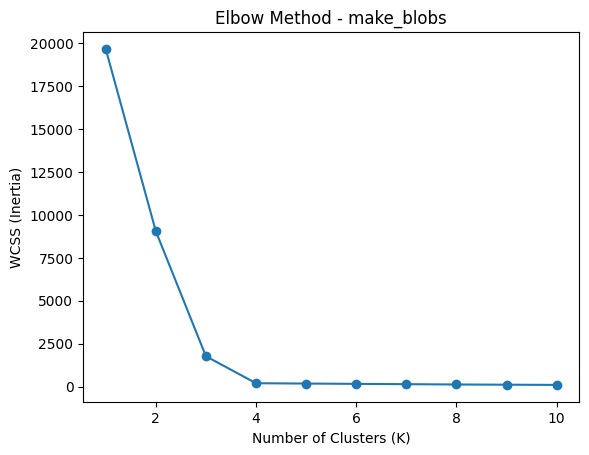

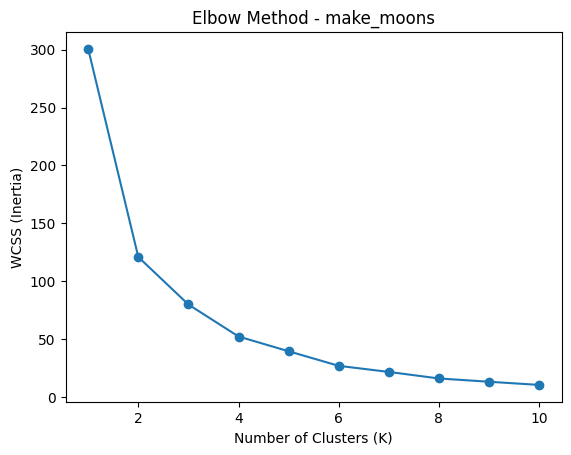

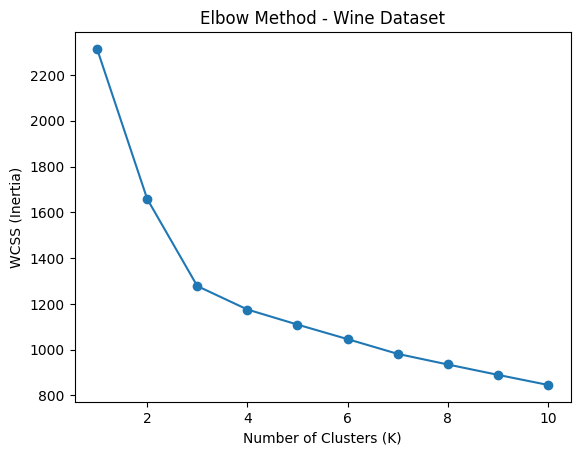

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs, make_moons, load_wine
from sklearn.preprocessing import StandardScaler

# Function to plot elbow curve
def elbow_method(X, title):
    wcss = []
    K_range = range(1, 11)

    for k in K_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        kmeans.fit(X)
        wcss.append(kmeans.inertia_)

    plt.figure()
    plt.plot(K_range, wcss, marker='o')
    plt.xlabel("Number of Clusters (K)")
    plt.ylabel("WCSS (Inertia)")
    plt.title(title)
    plt.show()


# 1. make_blobs dataset

X_blobs, _ = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=42)
elbow_method(X_blobs, "Elbow Method - make_blobs")

# 2. make_moons dataset

X_moons, _ = make_moons(n_samples=300, noise=0.05, random_state=42)
elbow_method(X_moons, "Elbow Method - make_moons")


# 3. Wine dataset

wine = load_wine()
X_wine = wine.data

# Feature scaling (mandatory for K-Means governance)
scaler = StandardScaler()
X_wine_scaled = scaler.fit_transform(X_wine)

elbow_method(X_wine_scaled, "Elbow Method - Wine Dataset")


**Question 6:** Generate synthetic data using make_blobs(n_samples=300, centers=4),
apply KMeans clustering, and visualize the results with cluster centers.
(Include your Python code and output in the code box below.)

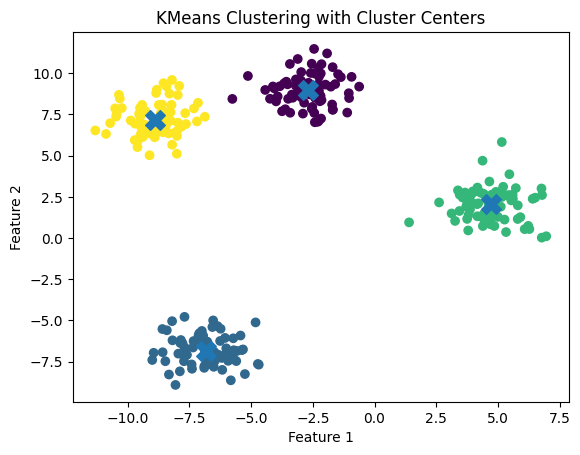

Cluster Centers:
[[-2.70981136  8.97143336]
 [-6.83235205 -6.83045748]
 [ 4.7182049   2.04179676]
 [-8.87357218  7.17458342]]


In [2]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Step 1: Generate synthetic data
X, y = make_blobs(n_samples=300, centers=4, random_state=42)

# Step 2: Apply KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)

# Step 3: Get cluster labels and centers
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# Step 4: Visualize clusters and centers
plt.scatter(X[:, 0], X[:, 1], c=labels)
plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=200)
plt.title("KMeans Clustering with Cluster Centers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Step 5: Print cluster centers
print("Cluster Centers:")
print(centers)


**Question 7:** Load the Wine dataset, apply StandardScaler , and then train a DBSCAN
model. Print the number of clusters found (excluding noise).
(Include your Python code and output in the code box below.)

In [3]:
# Import core libraries
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

# Step 1: Load the Wine dataset
wine = load_wine()
X = wine.data

# Step 2: Apply StandardScaler for feature normalization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Train DBSCAN model
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan.fit(X_scaled)

# Step 4: Extract cluster labels
labels = dbscan.labels_

# Step 5: Calculate number of clusters (excluding noise labeled as -1)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

# Print results
print("Number of clusters found (excluding noise):", n_clusters)


Number of clusters found (excluding noise): 0


**Question 8:** Generate moon-shaped synthetic data using
make_moons(n_samples=200, noise=0.1), apply DBSCAN, and highlight the outliers in
the plot.
(Include your Python code and output in the code box below.)

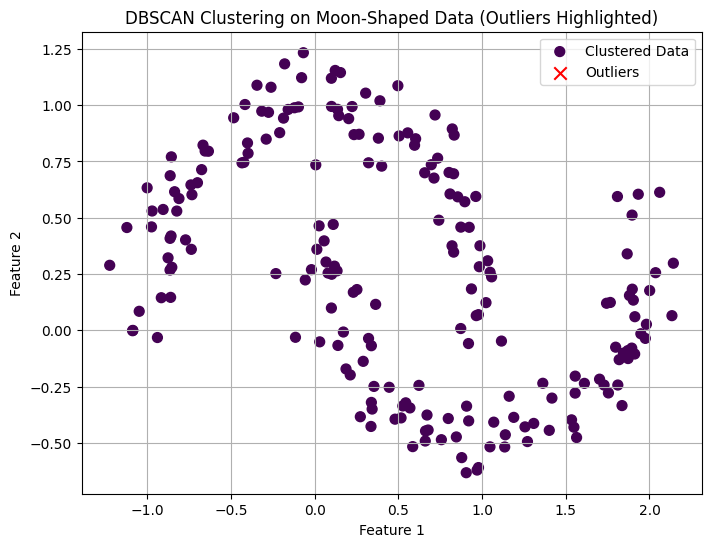

In [4]:
# Import core libraries for data generation, modeling, and visualization
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN

# Step 1: Generate moon-shaped synthetic dataset
X, y = make_moons(n_samples=200, noise=0.1, random_state=42)

# Step 2: Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(X)

# Step 3: Identify outliers (DBSCAN labels outliers as -1)
outliers = labels == -1

# Step 4: Visualization with clear segmentation
plt.figure(figsize=(8, 6))
plt.scatter(X[~outliers, 0], X[~outliers, 1],
            c=labels[~outliers], cmap='viridis',
            s=50, label='Clustered Data')

plt.scatter(X[outliers, 0], X[outliers, 1],
            c='red', marker='x', s=80, label='Outliers')

plt.title("DBSCAN Clustering on Moon-Shaped Data (Outliers Highlighted)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


**Question 9:** Load the Wine dataset, reduce it to 2D using PCA, then apply
Agglomerative Clustering and visualize the result in 2D with a scatter plot.
(Include your Python code and output in the code box below.)

Explained Variance Ratio: [0.36198848 0.1920749 ]


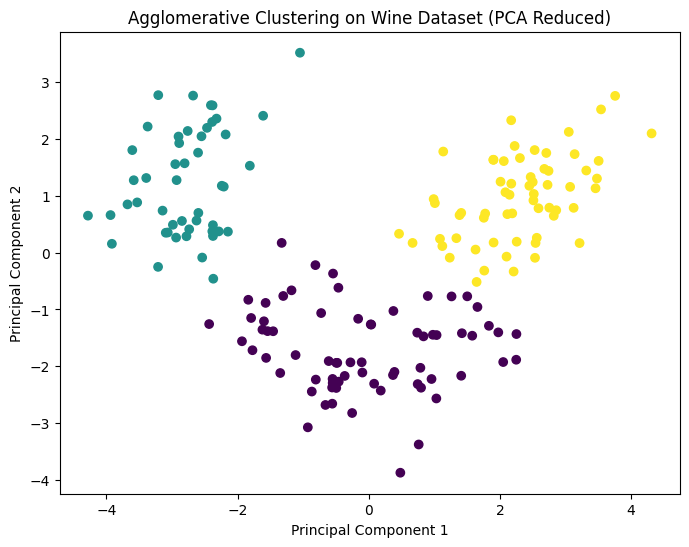

In [5]:
# Import core libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering

# Step 1: Load Wine dataset
wine = load_wine()
X = wine.data

# Step 2: Standardize features (critical for PCA performance)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Apply PCA to reduce data to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

# Step 4: Apply Agglomerative Clustering
cluster_model = AgglomerativeClustering(n_clusters=3, linkage='ward')
clusters = cluster_model.fit_predict(X_pca)

# Step 5: Visualize clusters in 2D
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Agglomerative Clustering on Wine Dataset (PCA Reduced)")
plt.show()


**Question 10:** You are working as a data analyst at an e-commerce company. The
marketing team wants to segment customers based on their purchasing behavior to run
targeted promotions. The dataset contains customer demographics and their product
purchase history across categories.      
Describe your real-world data science workflow using clustering:          
● Which clustering algorithm(s) would you use and why?       
● How would you preprocess the data (missing values, scaling)?       
● How would you determine the number of clusters?       
● How would the marketing team benefit from your clustering analysis?      
(Include your Python code and output in the code box below.)

In [6]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Sample customer dataset (simulated)
data = {
    'age': [25, 34, 45, 23, 35, 52, 46, 29],
    'annual_income': [40, 60, 80, 35, 65, 90, 85, 50],
    'total_spend': [200, 500, 800, 150, 550, 900, 850, 400]
}

df = pd.DataFrame(data)

# Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(scaled_data)

# Silhouette Score
score = silhouette_score(scaled_data, df['cluster'])

print(df)
print("Silhouette Score:", round(score, 3))


   age  annual_income  total_spend  cluster
0   25             40          200        2
1   34             60          500        1
2   45             80          800        0
3   23             35          150        2
4   35             65          550        1
5   52             90          900        0
6   46             85          850        0
7   29             50          400        1
Silhouette Score: 0.66
